# 1.0 Loading Historical Stock Prices

In [41]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

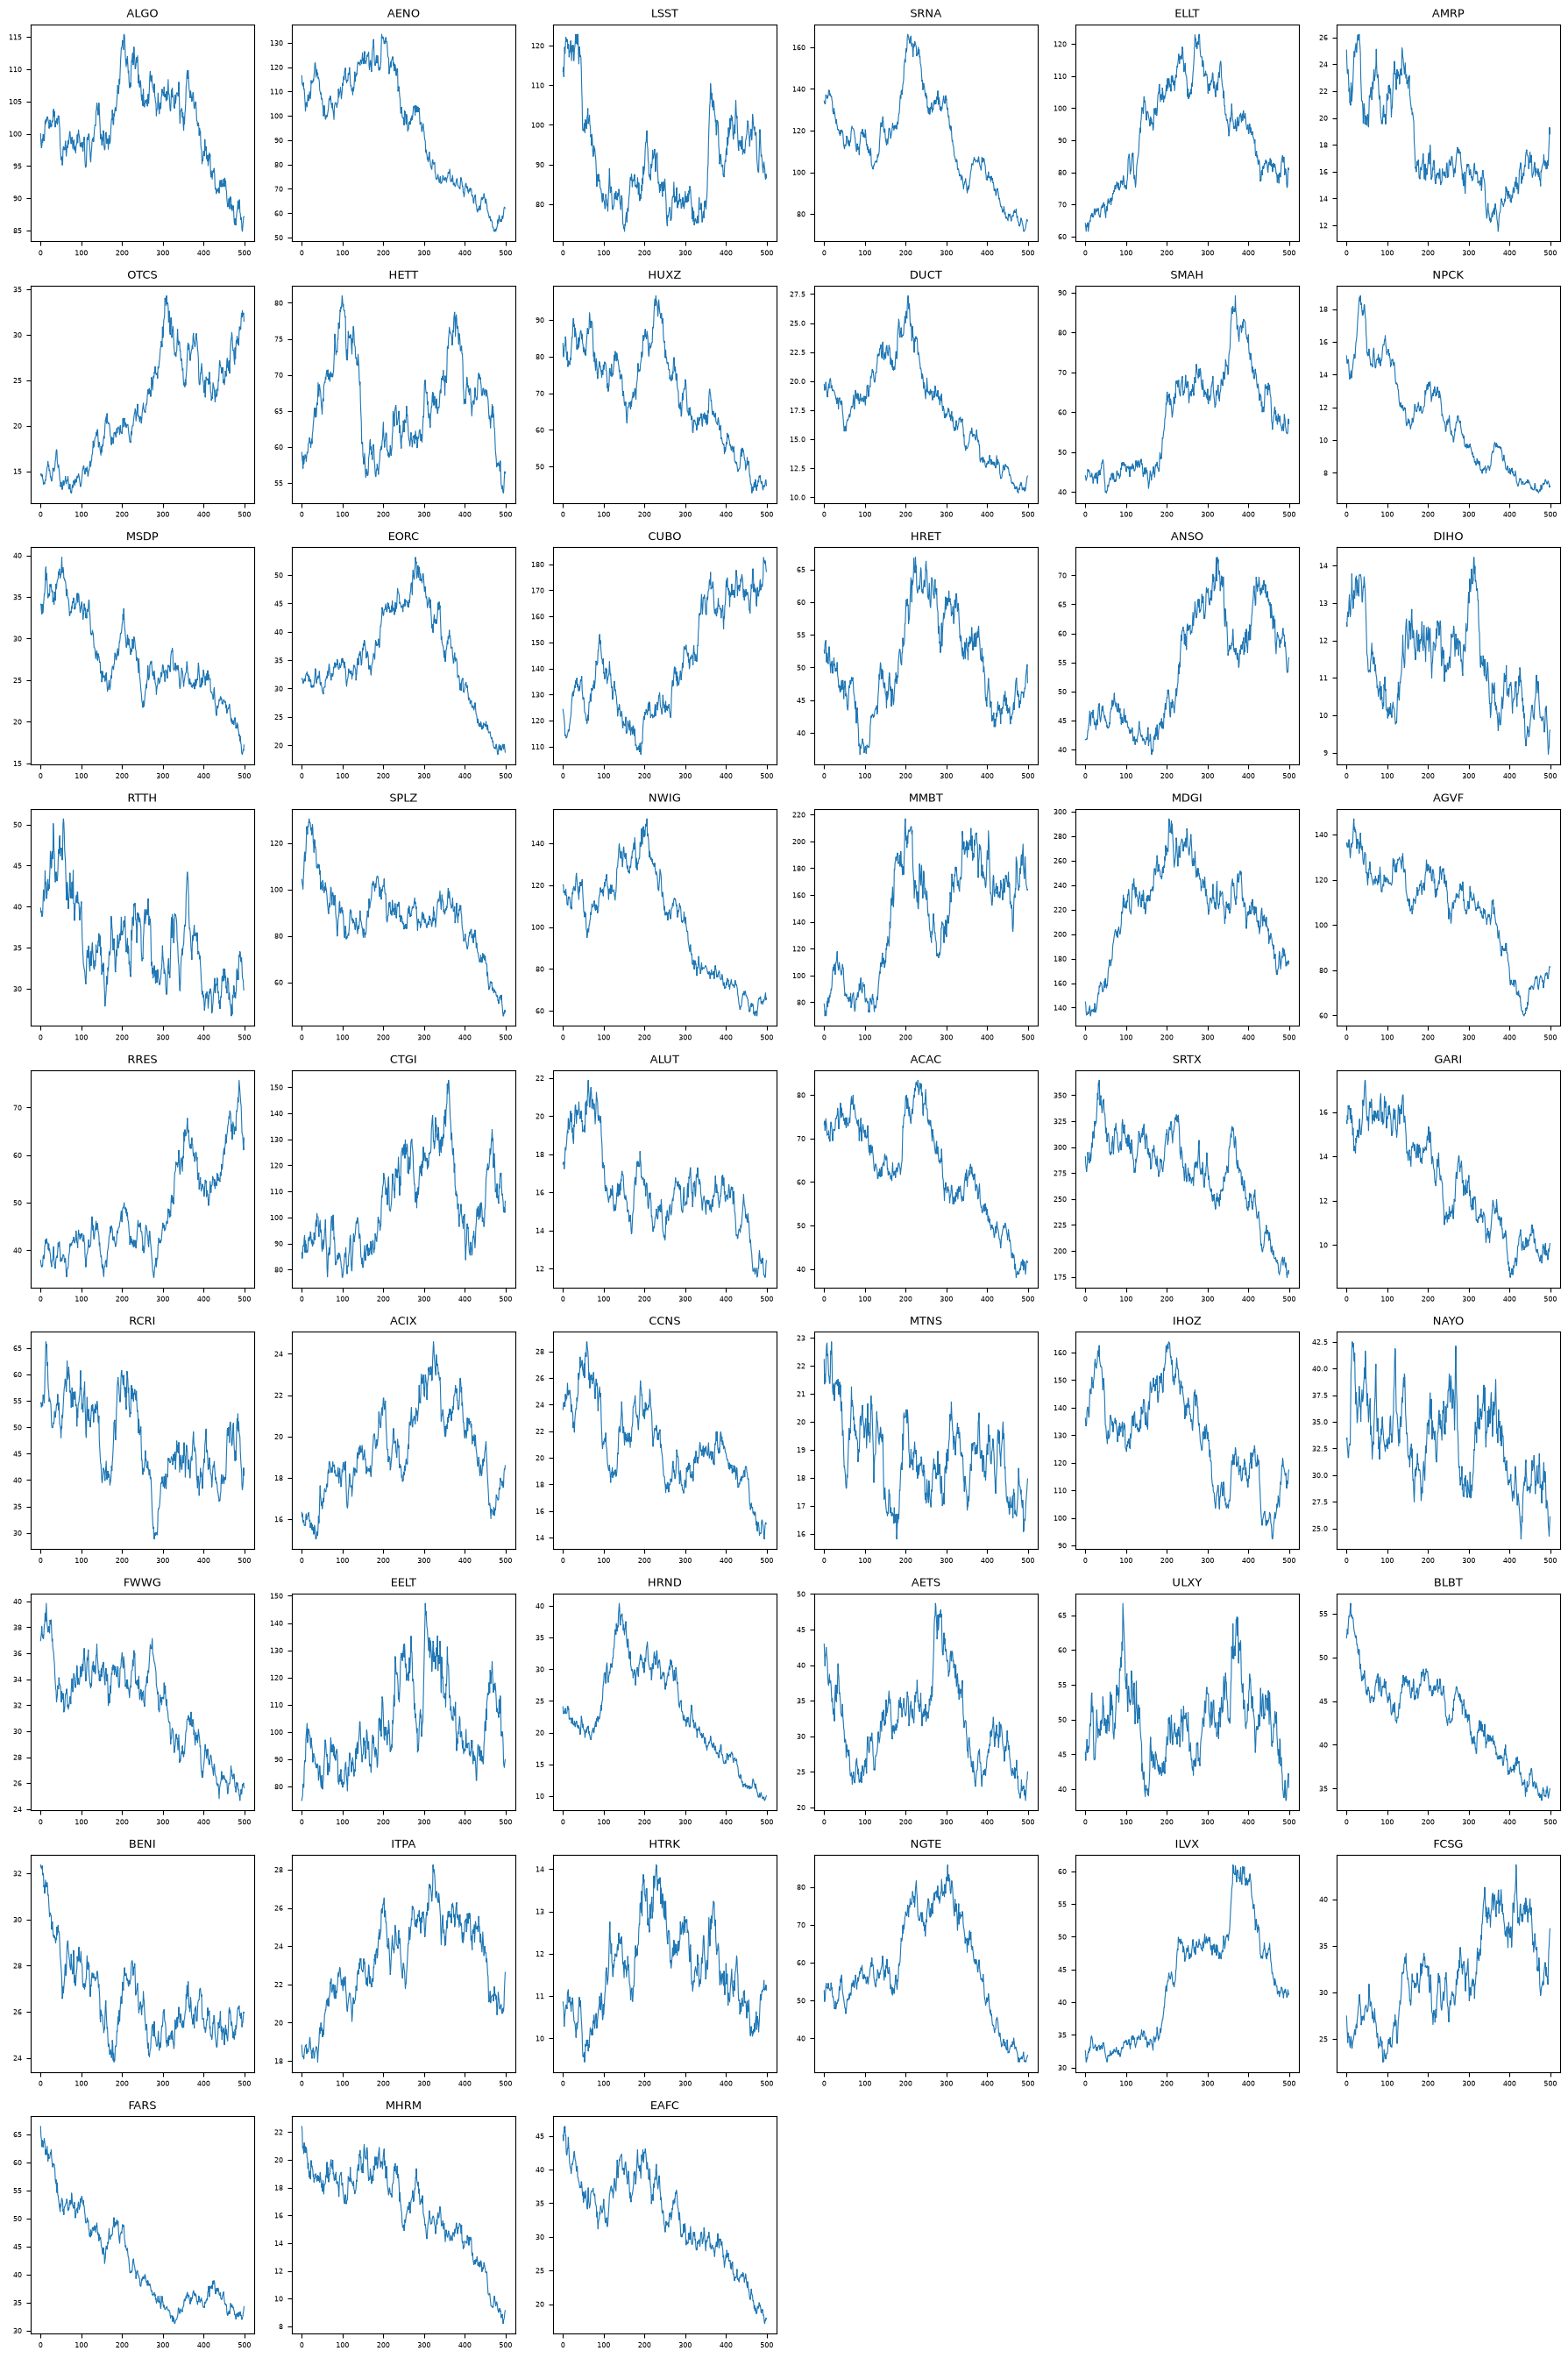

In [7]:
# load the data
df = pd.read_csv('prices.txt', sep=r'\s+')
tickers = df.columns
n = len(tickers)

ncols = 6
nrows = -(-n // ncols)  # ceiling division, so we always have enough rows

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 3 * nrows))
axes = axes.flatten()  # turn the grid of axes into a flat list, easier to loop over

for i, ticker in enumerate(tickers):
    axes[i].plot(df[ticker], linewidth=0.8)
    axes[i].set_title(ticker, fontsize=9)
    axes[i].tick_params(labelsize=6)

# hide any leftover empty boxes (51 tickers doesn't divide evenly into 6 columns)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [9]:
log_returns = np.log(df / df.shift(1)).dropna()

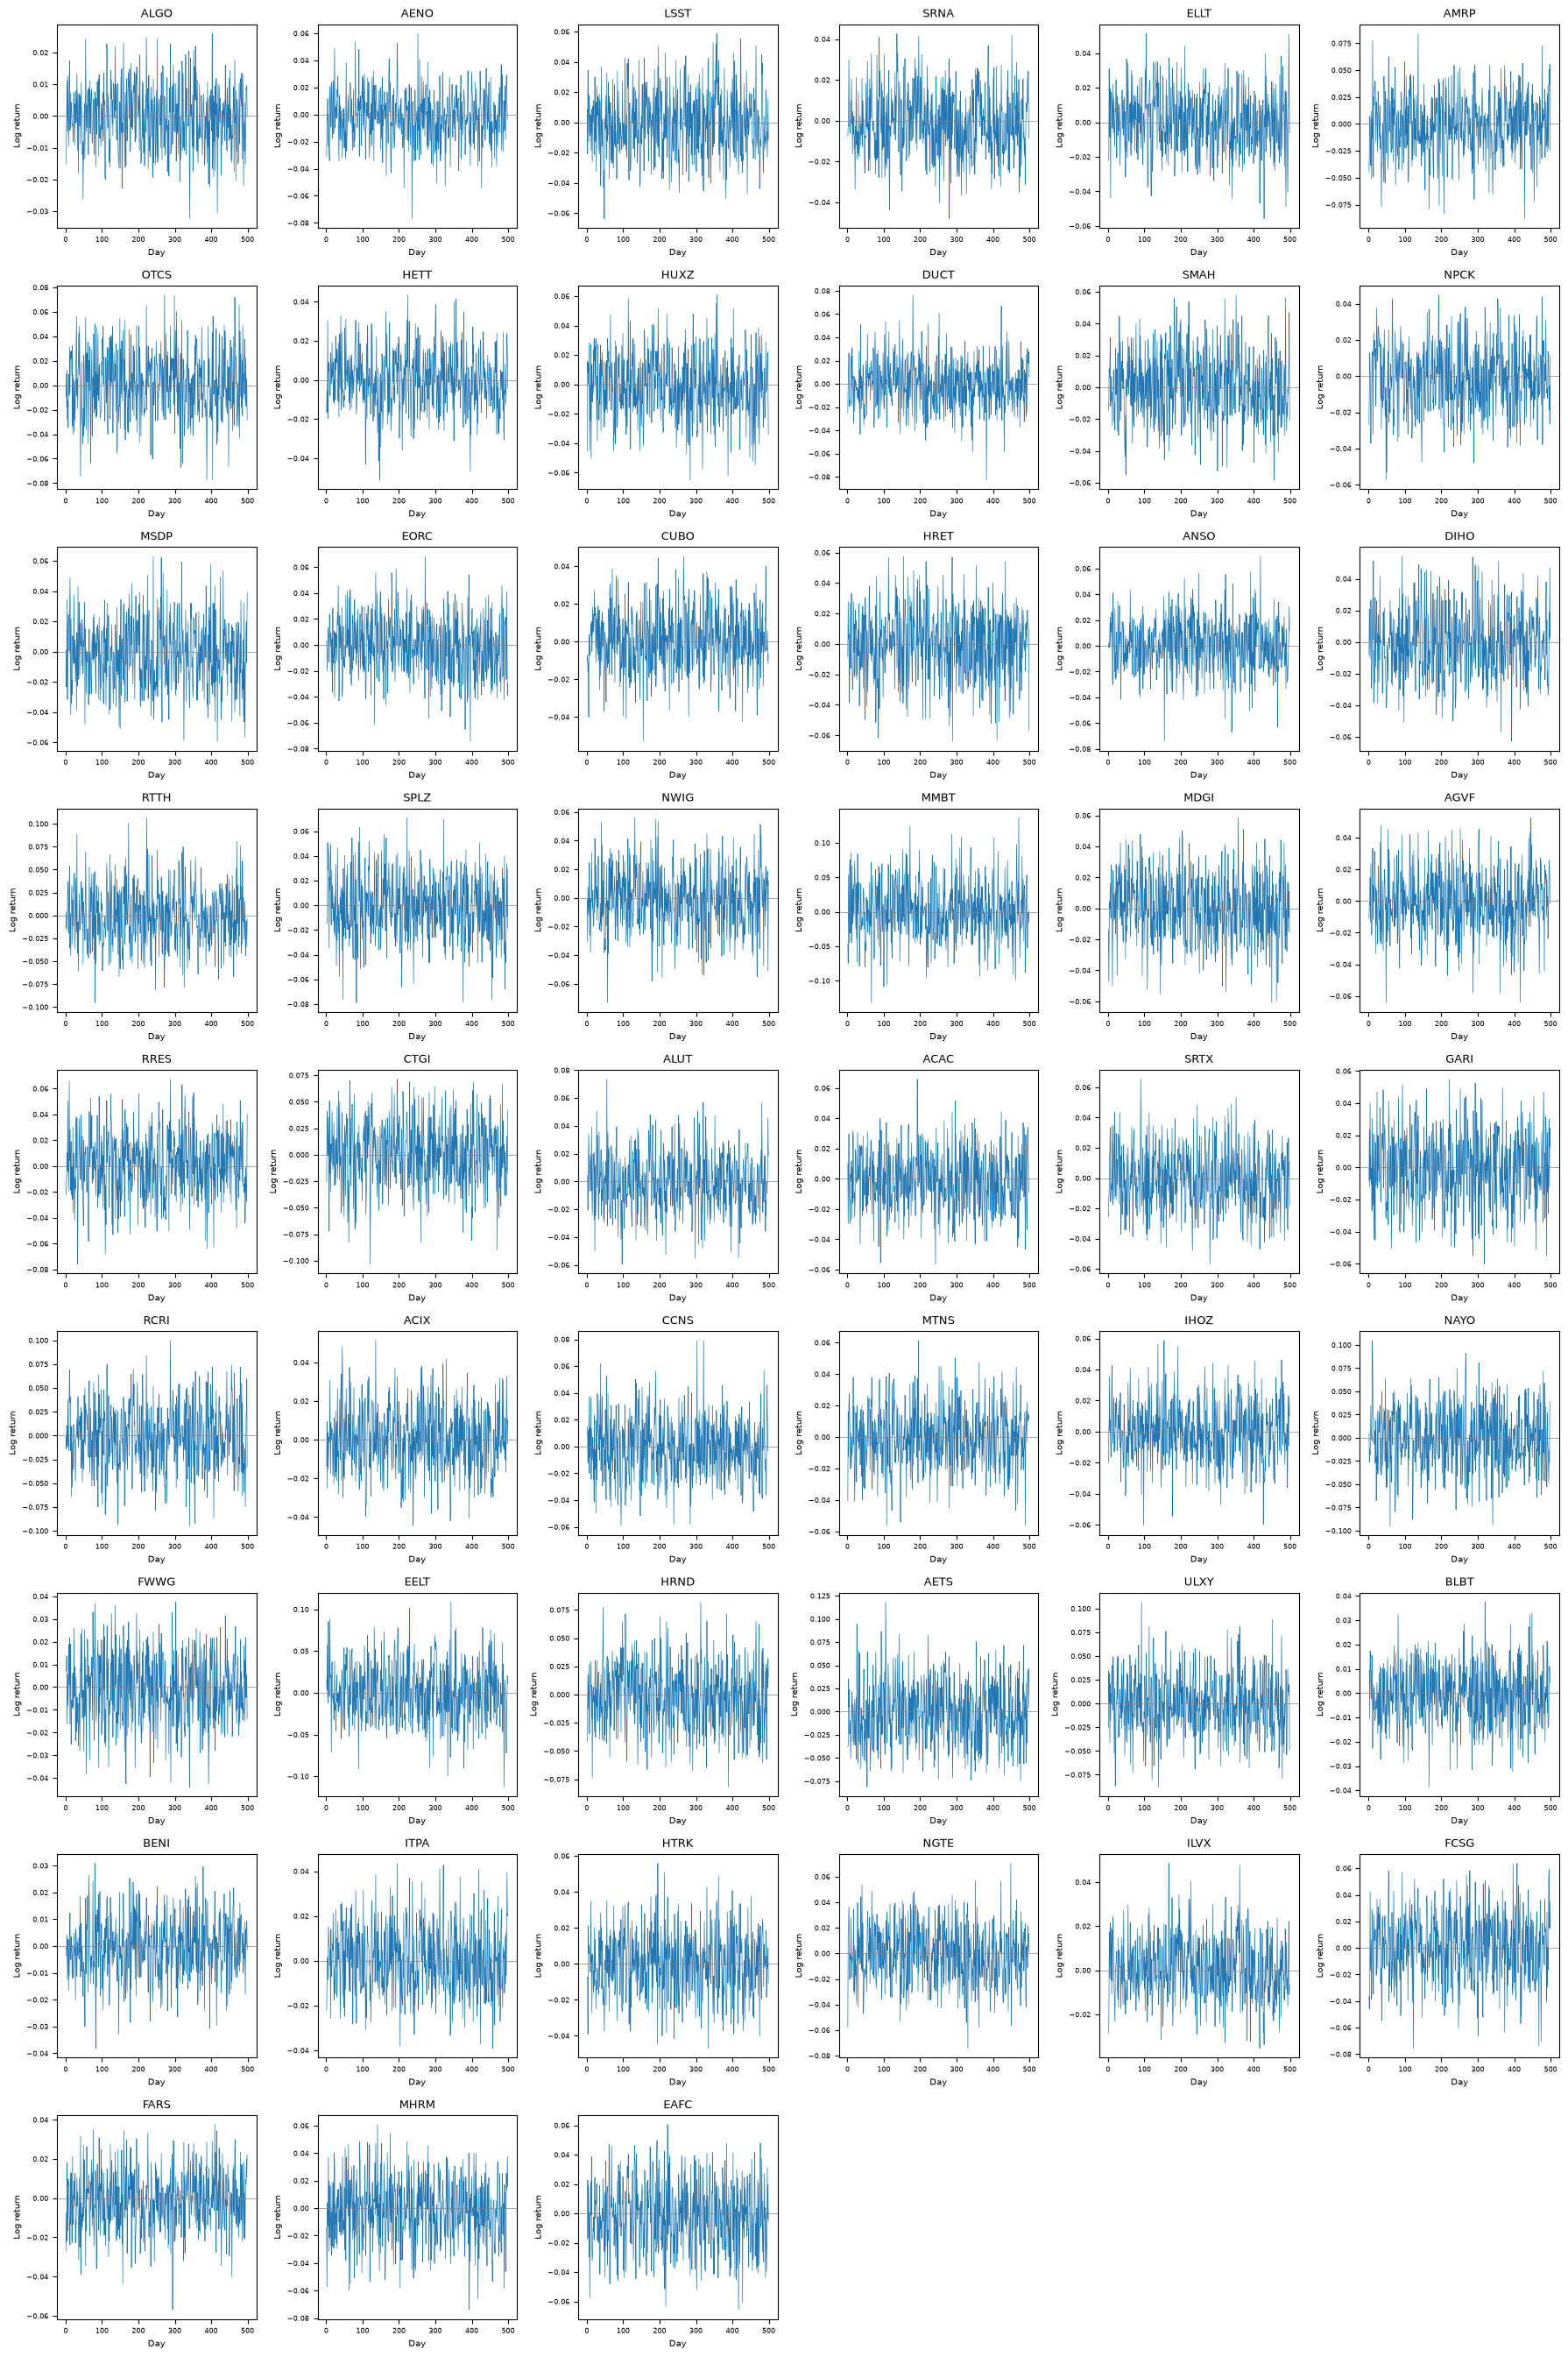

In [10]:
#Plotting returns for all tickers
tickers = log_returns.columns
n = len(tickers)
ncols = 6
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 3 * nrows))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].plot(log_returns[ticker], linewidth=0.5)
    axes[i].axhline(0, color='gray', linewidth=0.5)  # zero-line reference
    axes[i].set_title(ticker, fontsize=9)
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel('Day', fontsize=7)
    axes[i].set_ylabel('Log return', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# calcuating mean and std deviation of log returns for each ticker
mean_returns = log_returns.mean()
std_returns = log_returns.std()
mean_std_df = pd.DataFrame({'Mean': mean_returns, 'Std Dev': std_returns})
mean_std_df = mean_std_df.sort_values(by='Mean', ascending=False)
mean_std_df.head(10)  # Display top 10 tickers with highest mean returns


,Mean,Std Dev
OTCS,0.001529,0.026683
MMBT,0.001469,0.040939
RRES,0.001038,0.024536
CUBO,0.000710,0.016155
FCSG,0.000588,0.025045
ANSO,0.000582,0.020175
SMAH,0.000518,0.021298
ILVX,0.000468,0.013804
ELLT,0.000465,0.017305
CTGI,0.000413,0.030685


In [33]:
results = []
for ticker in log_returns.columns:
    r = log_returns[ticker]
    mean = r.mean()
    std = r.std()

    jb_stat, jb_p = stats.jarque_bera(r)

    results.append({
        'ticker': ticker,
        'mean': mean,
        'std': std,
        'jarque_bera_stat': jb_stat,
        'jarque_bera_pval': jb_p,
        'normal_at_5pct': jb_p > 0.05
    })

summary = pd.DataFrame(results)




pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
print(summary)

   ticker      mean       std  jarque_bera_stat  jarque_bera_pval  normal_at_5pct
0    ALGO -0.000276  0.009933          0.806693          0.668081            True
1    AENO -0.001262  0.018704          7.214101          0.027132           False
2    LSST -0.000543  0.021121          2.218463          0.329812            True
3    SRNA -0.001123  0.015749          1.460639          0.481755            True
4    ELLT  0.000465  0.017305          0.306642          0.857854            True
5    AMRP -0.000574  0.027713          1.980757          0.371436            True
6    OTCS  0.001529  0.026683          0.298511          0.861349            True
7    HETT -0.000100  0.014803          1.216371          0.544338            True
8    HUXZ -0.001251  0.021391          0.063242          0.968874            True
9    DUCT -0.001023  0.020915          7.455117          0.024051           False
10   SMAH  0.000518  0.021298          1.565731          0.457094            True
11   NPCK -0.001

In [34]:
from statsmodels.tsa.stattools import adfuller

adf_results = []
for ticker in df.columns:
    price_series = df[ticker].dropna()
    return_series = log_returns[ticker]

    # adfuller returns a tuple; index [1] is the p-value
    adf_price_p = adfuller(price_series, autolag='AIC')[1]
    adf_return_p = adfuller(return_series, autolag='AIC')[1]

    adf_results.append({
        'ticker': ticker,
        'adf_price_pval': adf_price_p,
        'adf_return_pval': adf_return_p,
        'price_stationary': adf_price_p < 0.05,   # low p = reject H0 = stationary
        'return_stationary': adf_return_p < 0.05
    })

adf_summary = pd.DataFrame(adf_results)
print(adf_summary)

print(f"\nPrices stationary: {adf_summary['price_stationary'].sum()} / {len(adf_summary)}")
print(f"Returns stationary: {adf_summary['return_stationary'].sum()} / {len(adf_summary)}")

   ticker  adf_price_pval  adf_return_pval  price_stationary  return_stationary
0    ALGO        0.720252     1.150655e-29             False               True
1    AENO        0.938123     0.000000e+00             False               True
2    LSST        0.095437     0.000000e+00             False               True
3    SRNA        0.856407     2.347567e-19             False               True
4    ELLT        0.418396     1.497900e-29             False               True
5    AMRP        0.301676     1.278533e-29             False               True
6    OTCS        0.771090     0.000000e+00             False               True
7    HETT        0.321092     1.846847e-26             False               True
8    HUXZ        0.833357     0.000000e+00             False               True
9    DUCT        0.875820     0.000000e+00             False               True
10   SMAH        0.559892     0.000000e+00             False               True
11   NPCK        0.791618     2.311099e-

In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box on SQUARED returns: if big moves are followed by big moves
# (regardless of direction), squared returns will be autocorrelated.
# H0 = no autocorrelation, i.e. constant volatility.
# p < 0.05 => reject H0 => volatility clustering IS present.

het_results = []
for ticker in log_returns.columns:
    r = log_returns[ticker]
    lb_pval = acorr_ljungbox(r**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

    het_results.append({
        'ticker': ticker,
        'ljungbox_pval': lb_pval,
        'has_vol_clustering': lb_pval < 0.05
    })

het_summary = pd.DataFrame(het_results)
print(het_summary)

print(f"\nInstruments with volatility clustering: {het_summary['has_vol_clustering'].sum()} / {len(het_summary)}")

   ticker  ljungbox_pval  has_vol_clustering
0    ALGO       0.317994               False
1    AENO       0.267521               False
2    LSST       0.544907               False
3    SRNA       0.903827               False
4    ELLT       0.221046               False
5    AMRP       0.917354               False
6    OTCS       0.474521               False
7    HETT       0.118760               False
8    HUXZ       0.702077               False
9    DUCT       0.607817               False
10   SMAH       0.489710               False
11   NPCK       0.780705               False
12   MSDP       0.499190               False
13   EORC       0.406638               False
14   CUBO       0.477067               False
15   HRET       0.226647               False
16   ANSO       0.296514               False
17   DIHO       0.394042               False
18   RTTH       0.931855               False
19   SPLZ       0.886378               False
20   NWIG       0.682642               False
21   MMBT 

# 3.0 Relationship between assets

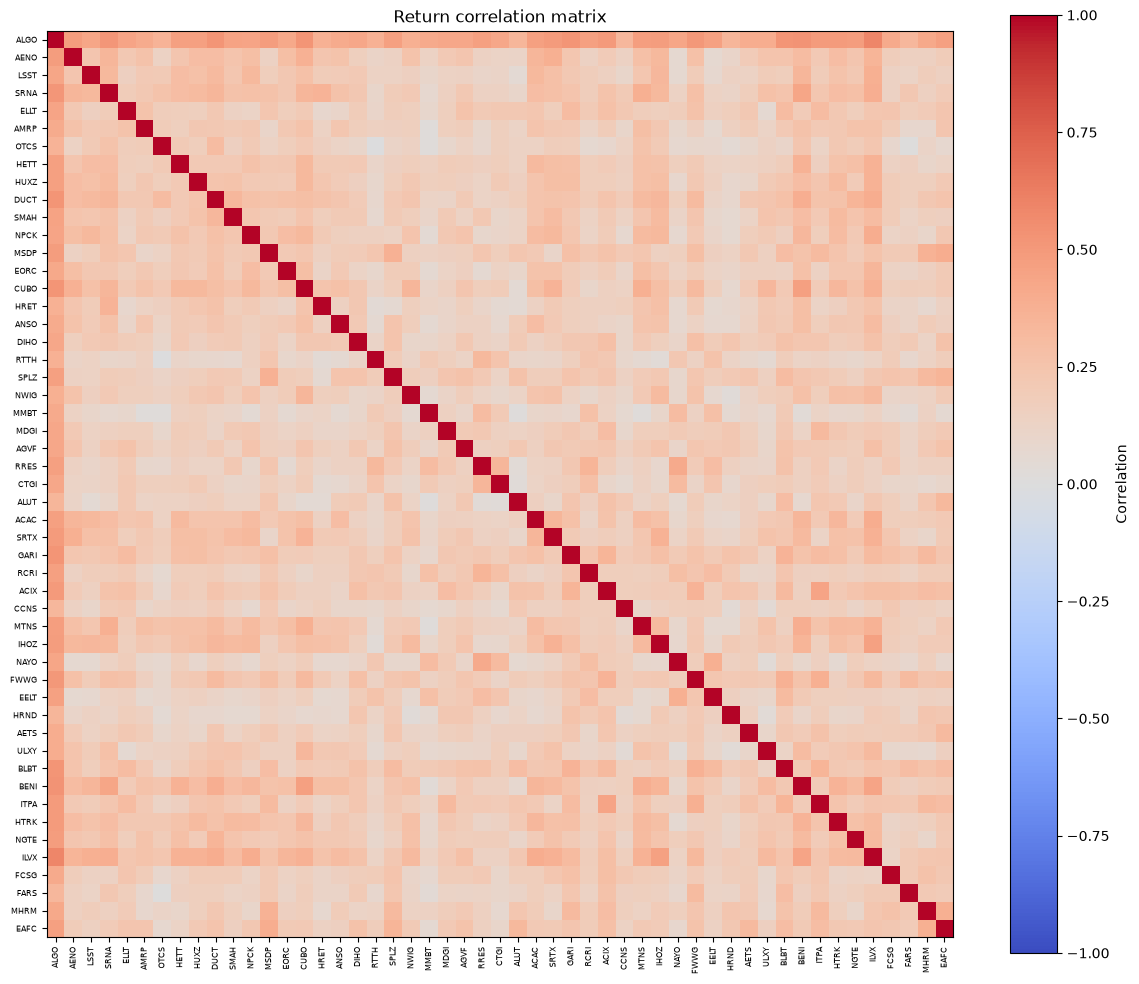

In [ ]:
import matplotlib.pyplot as plt

corr = log_returns.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)
plt.title('Return correlation matrix')
plt.tight_layout()
plt.show()

In [40]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().dropna()
corr_pairs = corr_pairs.sort_values(ascending=False)

print("Strongest positive correlations:")
print(corr_pairs.head(10))

print("\nWeakest positive correlations:")
print(corr_pairs.tail(10))

Strongest positive correlations:
ALGO  ILVX    0.590042
      BENI    0.526093
      CUBO    0.523170
      BLBT    0.522108
      DUCT    0.521776
      GARI    0.519409
      SRNA    0.512491
      FWWG    0.500165
      ACIX    0.493402
      ITPA    0.490473
dtype: float64

Weakest positive correlations:
HRND  ULXY    0.034784
RRES  ALUT    0.031880
NWIG  HRND    0.029658
CTGI  ALUT    0.023735
AMRP  MMBT    0.021828
MMBT  MTNS    0.021232
OTCS  MMBT    0.016531
MMBT  ALUT    0.013208
OTCS  FARS    0.007028
      RTTH   -0.000800
dtype: float64


In [42]:
algo_returns = log_returns['ALGO']

beta_results = []
for ticker in log_returns.columns:
    if ticker == 'ALGO':
        continue
    y = log_returns[ticker]
    X = sm.add_constant(algo_returns)  # adds an intercept term to the regression

    model = sm.OLS(y, X).fit()
    beta = model.params['ALGO']
    r_squared = model.rsquared
    pval = model.pvalues['ALGO']

    beta_results.append({
        'ticker': ticker,
        'beta_to_algo': beta,
        'r_squared': r_squared,
        'pval': pval
    })

beta_summary = pd.DataFrame(beta_results).sort_values('r_squared', ascending=False)
print(beta_summary)
print(f"\nAverage R-squared across all instruments: {beta_summary['r_squared'].mean():.3f}")

   ticker  beta_to_algo  r_squared          pval
45   ILVX      0.820024   0.348149  3.952182e-48
41   BENI      0.597303   0.276773  7.243214e-37
13   CUBO      0.850922   0.273707  2.083880e-36
40   BLBT      0.647289   0.272597  3.052223e-36
8    DUCT      1.098704   0.272250  3.438103e-36
28   GARI      1.157788   0.269786  8.000834e-36
2    SRNA      0.812588   0.262647  9.093399e-35
35   FWWG      0.770427   0.250165  6.036977e-33
30   ACIX      0.820936   0.243445  5.617248e-32
42   ITPA      0.752897   0.240564  1.453009e-31
43   HTRK      0.866805   0.235487  7.690734e-31
27   SRTX      0.985647   0.235178  8.508679e-31
33   IHOZ      0.904516   0.234226  1.161269e-30
11   MSDP      1.074888   0.230420  4.013565e-30
44   NGTE      1.089816   0.228590  7.270343e-30
0    AENO      0.900283   0.228568  7.320879e-30
32   MTNS      0.929501   0.226942  1.240009e-29
23   RRES      1.157933   0.219719  1.270395e-28
29   RCRI      1.589874   0.218937  1.632280e-28
7    HUXZ      1.006

# 4.0 Possible Signal Explorations